# 🧠📷 CNN Demo: Image Classification with Fashion-MNIST

This notebook demonstrates a simple Convolutional Neural Network (CNN) trained on the Fashion-MNIST dataset — a collection of 28×28 grayscale images representing 10 clothing categories (e.g., T-shirt, bag, sneaker).

**Network architecture:**
- Input: 1-channel (grayscale) 28×28 image
- 2 convolutional layers with ReLU activation and max pooling
- 1 fully connected layer for feature aggregation
- Output: 10 units (one for each class)

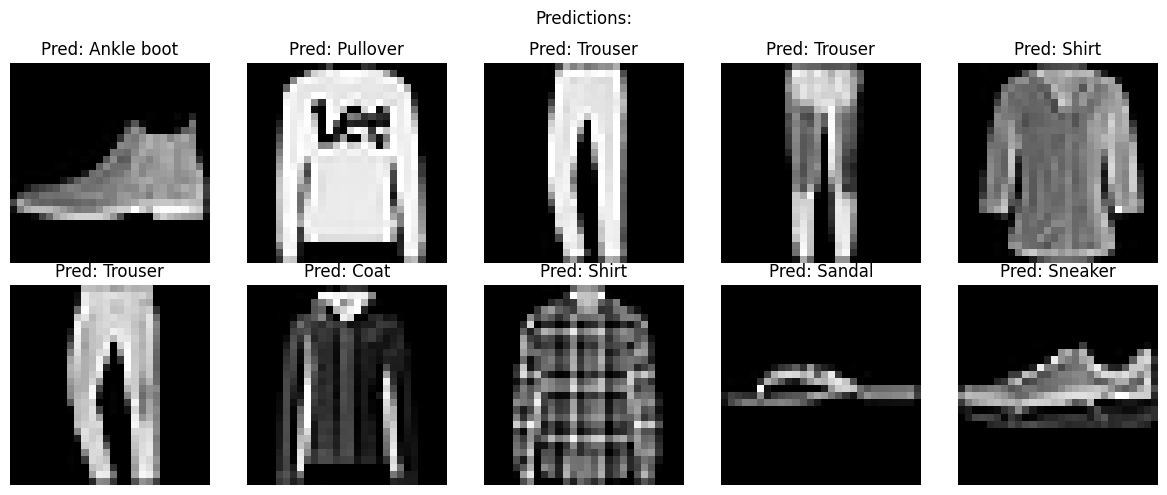

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# dataset
transform = transforms.Compose([transforms.ToTensor()])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

# simple CNN arch
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# model trained for just 1 epoch (lasts long...)
model.train()
for epoch in range(1):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# Eval
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Plots of a few predictions
classes = train_set.classes
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axs.flatten()):
    img = images[i].cpu().squeeze()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {classes[preds[i]]}")
    ax.axis('off')

plt.suptitle("Predictions:")
plt.tight_layout()
plt.show()


## Extracting and visualizing the learned filters from the first conv layer

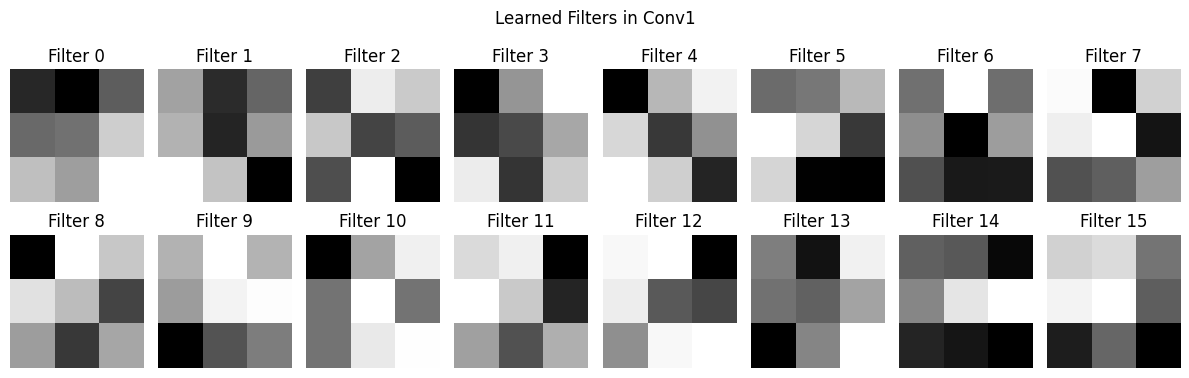

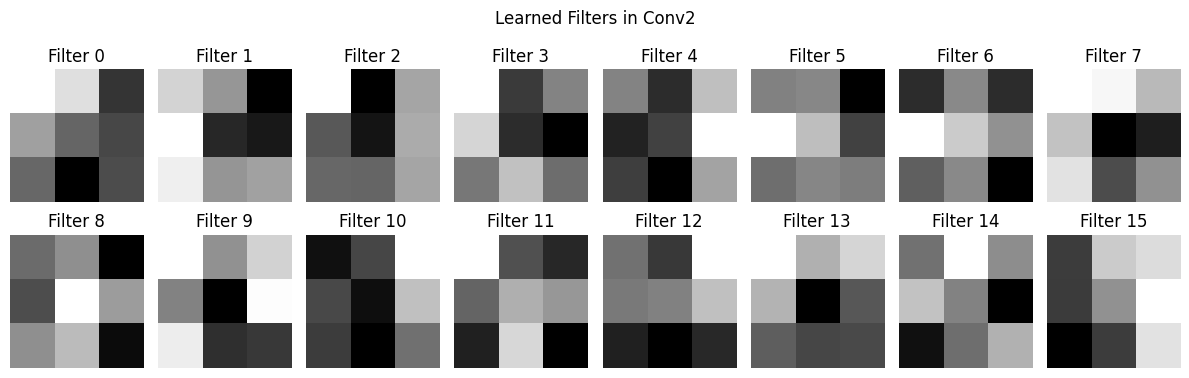

In [17]:
filters = model.conv1.weight.data.cpu()

fig, axs = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(filters[i][0], cmap='gray')
    ax.axis('off')
    ax.set_title(f"Filter {i}")

plt.suptitle("Learned Filters in Conv1")
plt.tight_layout()
plt.show()


filters2 = model.conv2.weight.data.cpu()

fig, axs = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(filters2[i][0], cmap='gray')
    ax.axis('off')
    ax.set_title(f"Filter {i}")

plt.suptitle("Learned Filters in Conv2")
plt.tight_layout()
plt.show()

## Activations from Conv1

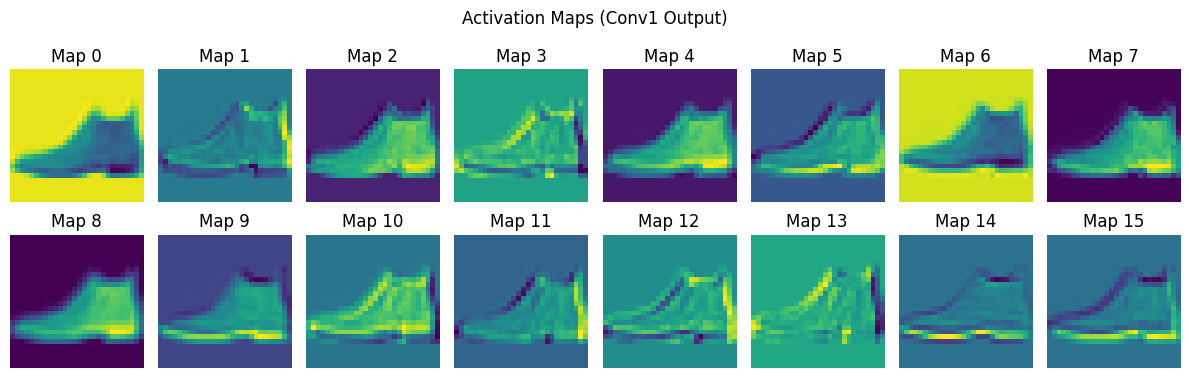

In [18]:
with torch.no_grad():
    image = images[0].unsqueeze(0).to(device)  # first test image
    activation = model.conv1(image)

fig, axs = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(activation[0, i].cpu(), cmap='viridis')
    ax.axis('off')
    ax.set_title(f"Map {i}")

plt.suptitle("Activation Maps (Conv1 Output)")
plt.tight_layout()
plt.show()




## Activations from Conv2

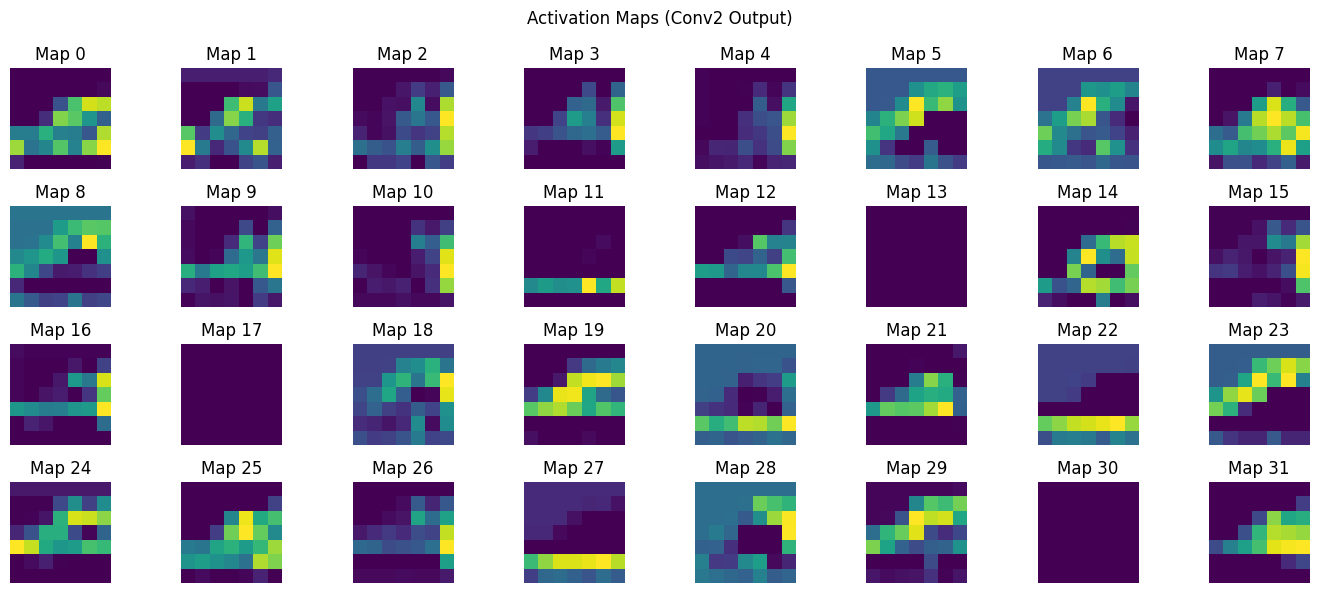

In [19]:
with torch.no_grad():
    image = images[0].unsqueeze(0).to(device)
    x = model.pool(torch.relu(model.conv1(image)))
    conv2_output = model.pool(torch.relu(model.conv2(x)))

fig, axs = plt.subplots(4, 8, figsize=(14, 6))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(conv2_output[0, i].cpu(), cmap='viridis')
    ax.axis('off')
    ax.set_title(f"Map {i}")
plt.suptitle("Activation Maps (Conv2 Output)")
plt.tight_layout()
plt.show()